<a href="https://colab.research.google.com/github/cristinasarakefi-art/TugasAkhirS1/blob/main/Skrip%20yang%20dipakai%20di%20Skripsi%2012Untitled26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== 1. PUSTAKA DAN SISTEM BERHASIL DIINSIALISASI ===

=== MEMBACA FILE DATASET '/content/Data Mentah Penelitian Skripsi 5.csv' ===
Total Data Mahasiswa : 100 Baris
Total Kolom Variabel : 9 Kolom

[INFO] Data Hasil Label Encoding Berhasil Disimpan.
[INFO] Data Hasil Min-Max Scaling Berhasil Disimpan.

=== PEMBAGIAN DATASET STRATIFIED (80:20) ===
Jumlah Data Latih (Training Set) : 80 Mahasiswa
Jumlah Data Uji (Testing Set)   : 20 Mahasiswa

=== 11 TETANGGA TERDEKAT UNTUK DATA UJI 1 (GERSON YULIUS MARIA NAHAK) ===


,Indeks Data Latih,Nama Mahasiswa,Peminatan,Euclidean Distance
0,20,Victoria christin Tokan,Teknik Komputer & Kendali,0.1826
1,57,Yohana Palestrina Kobesi,Teknik Komputer & Kendali,0.2353
2,7,Vickry Adinarto Fuah,Teknik Komputer & Kendali,0.2682
3,77,Epin Modjo,Teknik Komputer & Kendali,0.2719
4,9,Yedija Wiliems Mooy,Teknik Komputer & Kendali,0.3178
5,44,Reynaldi Hadi Djo,Teknik Komputer & Kendali,0.3292
6,22,OVI HALENA TALAEN,Teknik Komputer & Kendali,0.3458
7,73,cristo sutiray,Teknik Komputer & Kendali,0.4040
8,21,Phylia Chisty Boimau,Teknik Komputer & Kendali,0.4104
9,26,Aldion Frankie Djahe,Teknik Komputer & Kendali,0.4279


               HASIL EVALUASI MODEL K-NN UNTUK NILAI K = 3
Akurasi Sistem : 90.00%

Classification Report:
                           precision    recall  f1-score   support

    Teknik Tenaga Listrik       1.00      0.71      0.83         7
    Teknik Telekomunikasi       0.88      1.00      0.93         7
Teknik Komputer & Kendali       0.86      1.00      0.92         6

                 accuracy                           0.90        20
                macro avg       0.91      0.90      0.90        20
             weighted avg       0.91      0.90      0.90        20



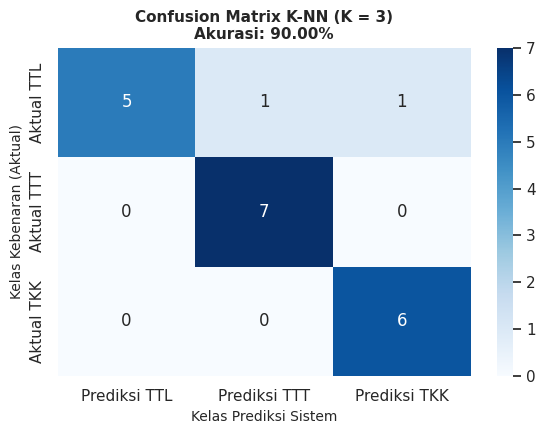

               HASIL EVALUASI MODEL K-NN UNTUK NILAI K = 5
Akurasi Sistem : 85.00%

Classification Report:
                           precision    recall  f1-score   support

    Teknik Tenaga Listrik       1.00      0.86      0.92         7
    Teknik Telekomunikasi       0.70      1.00      0.82         7
Teknik Komputer & Kendali       1.00      0.67      0.80         6

                 accuracy                           0.85        20
                macro avg       0.90      0.84      0.85        20
             weighted avg       0.89      0.85      0.85        20



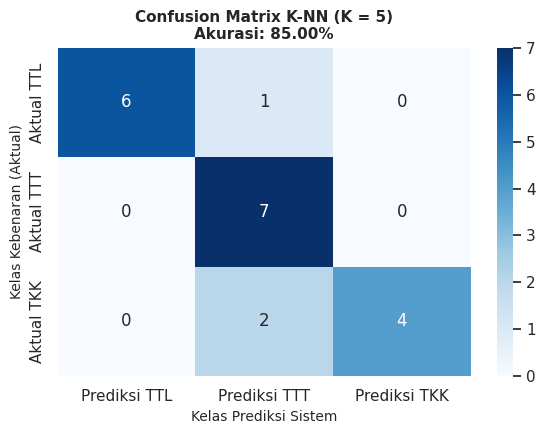

               HASIL EVALUASI MODEL K-NN UNTUK NILAI K = 7
Akurasi Sistem : 80.00%

Classification Report:
                           precision    recall  f1-score   support

    Teknik Tenaga Listrik       1.00      0.57      0.73         7
    Teknik Telekomunikasi       0.78      1.00      0.88         7
Teknik Komputer & Kendali       0.71      0.83      0.77         6

                 accuracy                           0.80        20
                macro avg       0.83      0.80      0.79        20
             weighted avg       0.84      0.80      0.79        20



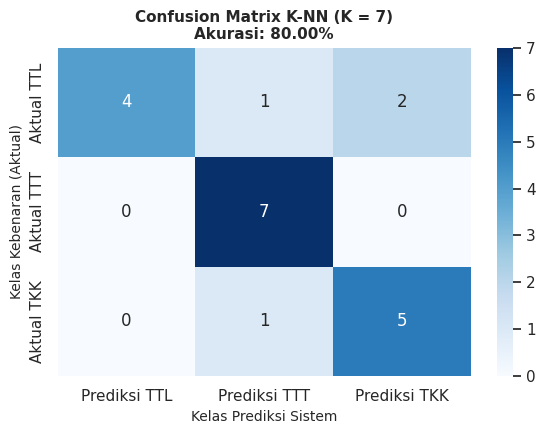

               HASIL EVALUASI MODEL K-NN UNTUK NILAI K = 9
Akurasi Sistem : 80.00%

Classification Report:
                           precision    recall  f1-score   support

    Teknik Tenaga Listrik       1.00      0.57      0.73         7
    Teknik Telekomunikasi       0.78      1.00      0.88         7
Teknik Komputer & Kendali       0.71      0.83      0.77         6

                 accuracy                           0.80        20
                macro avg       0.83      0.80      0.79        20
             weighted avg       0.84      0.80      0.79        20



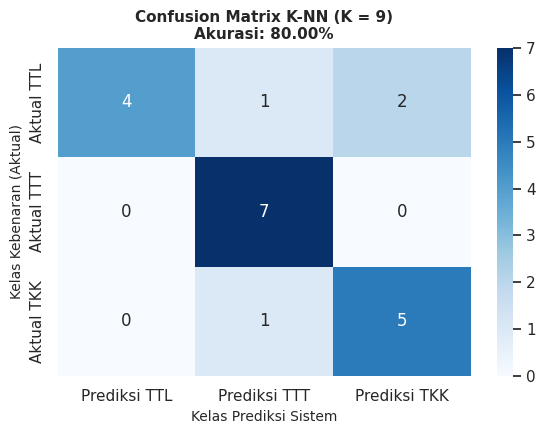

               HASIL EVALUASI MODEL K-NN UNTUK NILAI K = 11
Akurasi Sistem : 80.00%

Classification Report:
                           precision    recall  f1-score   support

    Teknik Tenaga Listrik       1.00      0.71      0.83         7
    Teknik Telekomunikasi       0.70      1.00      0.82         7
Teknik Komputer & Kendali       0.80      0.67      0.73         6

                 accuracy                           0.80        20
                macro avg       0.83      0.79      0.79        20
             weighted avg       0.83      0.80      0.80        20



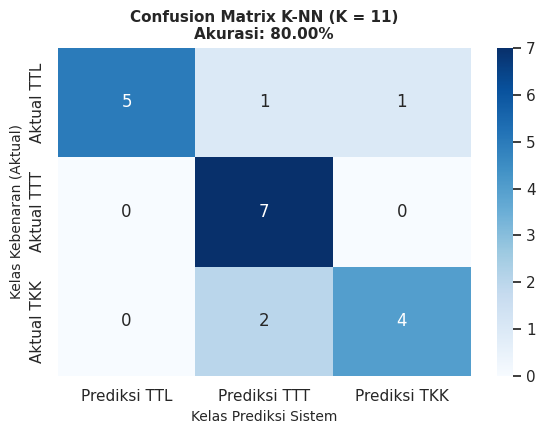


=== TABEL HASIL PENGUJIAN STRATIFIED 5-FOLD CROSS VALIDATION ===


Parameter K,Fold 1 (%),Fold 2 (%),Fold 3 (%),Fold 4 (%),Fold 5 (%),Rata-Rata Akurasi (%),Standar Deviasi (%)
K = 3,75.0,95.0,95.0,100.0,95.0,92.0,8.72
K = 5,80.0,85.0,90.0,100.0,95.0,90.0,7.07
K = 7,80.0,90.0,90.0,100.0,90.0,90.0,6.32
K = 9,85.0,85.0,85.0,100.0,100.0,91.0,7.35
K = 11,85.0,90.0,95.0,100.0,100.0,94.0,5.83


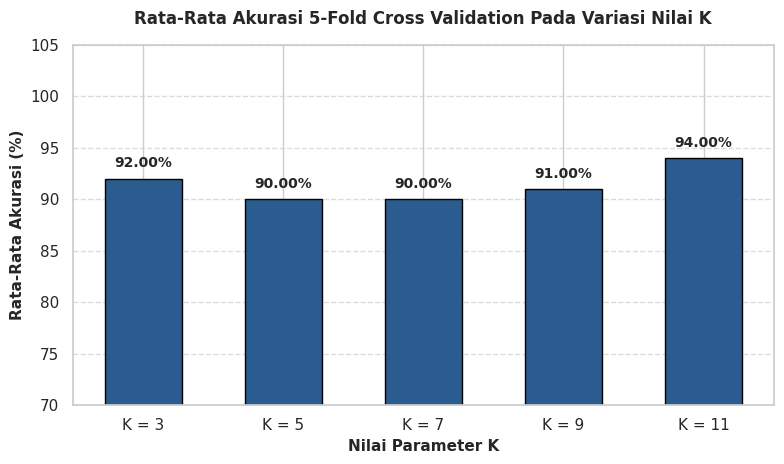

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Tampilan seaborn
sns.set_theme(style="whitegrid")
print("=== 1. PUSTAKA DAN SISTEM BERHASIL DIINSIALISASI ===")

# ==============================================================================
# 2. MEMBACA FILE DATASET MENTAH
# ==============================================================================
nama_file = '/content/Data Mentah Penelitian Skripsi 5.csv'
df = pd.read_csv(nama_file, sep=';', decimal=',')

# Pembersihan whitespace pada target
df['Bidang Minat'] = df['Bidang Minat'].astype(str).str.strip()

print(f"\n=== MEMBACA FILE DATASET '{nama_file}' ===")
print(f"Total Data Mahasiswa : {df.shape[0]} Baris")
print(f"Total Kolom Variabel : {df.shape[1]} Kolom\n")

# ==============================================================================
# 3. TAHAP 1: PRA-PEMROSESAN DATA (LABEL ENCODING)
# ==============================================================================
konversi_nilai = {
    'A': 4.00, 'A-': 3.75, 'AB': 3.50, 'B+': 3.25, 'B': 3.00,
    'B-': 2.75, 'BC': 2.50, 'C+': 2.25, 'C': 2.00, 'C-': 1.75,
    'D+': 1.50, 'D': 1.00, 'E': 0.00
}

kolom_mk = [
    'Nilai mata kuliah Dasar Tenaga Listrik ',
    'Nilai mata kuliah  Dasar Teknik Telekomunikasi',
    'Nilai mata kuliah Dasar Pemrograman Komputer'
]

encoded_cols = []
for col in kolom_mk:
    nama_enc = col.strip() + '_Encode'
    df[nama_enc] = df[col].astype(str).str.strip().map(konversi_nilai)
    encoded_cols.append(nama_enc)

# Konversi Kolom Numerik IPK dan Skor Minat
df['IPK_Num'] = df['IPK Semester 3'].astype(str).str.replace(',', '.').astype(float)
df['Minat_TTL_Num'] = df['Nilai Skor Minat TTL'].astype(str).str.replace(',', '.').astype(float)
df['Minat_TTT_Num'] = df['Nilai Skor Minat TTT'].astype(str).str.replace(',', '.').astype(float)
df['Minat_TKK_Num'] = df['Nilai Skor Minat TKK'].astype(str).str.replace(',', '.').astype(float)

# Menyimpan Data Hasil Label Encoding
df.to_csv('Data_Hasil_Label_Encoding.csv', sep=';', index=False, decimal=',')
print("[INFO] Data Hasil Label Encoding Berhasil Disimpan.")

# ==============================================================================
# 4. TAHAP 2: NORMALISASI DATA (MIN-MAX SCALING)
# ==============================================================================
def min_max_scaling(series, custom_min=None, custom_max=None):
    val_min = custom_min if custom_min is not None else series.min()
    val_max = custom_max if custom_max is not None else series.max()
    if val_max == val_min:
        return series
    return (series - val_min) / (val_max - val_min)

df['Norm_IPK_Num'] = min_max_scaling(df['IPK_Num'], 0, 4)
df['Norm_' + encoded_cols[0]] = min_max_scaling(df[encoded_cols[0]], 0, 4)
df['Norm_' + encoded_cols[1]] = min_max_scaling(df[encoded_cols[1]], 0, 4)
df['Norm_' + encoded_cols[2]] = min_max_scaling(df[encoded_cols[2]], 0, 4)
df['Norm_Minat_TTL_Num'] = min_max_scaling(df['Minat_TTL_Num'], 7, 35)
df['Norm_Minat_TTT_Num'] = min_max_scaling(df['Minat_TTT_Num'], 7, 35)
df['Norm_Minat_TKK_Num'] = min_max_scaling(df['Minat_TKK_Num'], 7, 35)

# Menyusun DataFrame Fitur Utama (X) dan Target (y)
fitur_kolom = [
    'Norm_IPK_Num',
    'Norm_' + encoded_cols[0],
    'Norm_' + encoded_cols[1],
    'Norm_' + encoded_cols[2],
    'Norm_Minat_TTL_Num',
    'Norm_Minat_TTT_Num',
    'Norm_Minat_TKK_Num'
]

X = df[fitur_kolom]
y = df['Bidang Minat']

# Menyimpan Data Hasil Normalisasi
df.to_csv('Data_Hasil_MinMax_Scaling.csv', sep=';', index=False, decimal=',')
print("[INFO] Data Hasil Min-Max Scaling Berhasil Disimpan.")

# ==============================================================================
# 5. TAHAP 3: PEMBAGIAN DATASET (80% TRAINING : 20% TESTING)
# ==============================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"\n=== PEMBAGIAN DATASET STRATIFIED (80:20) ===")
print(f"Jumlah Data Latih (Training Set) : {len(X_train)} Mahasiswa")
print(f"Jumlah Data Uji (Testing Set)   : {len(X_test)} Mahasiswa")

# ==============================================================================
# 6. TAHAP 4: PERHITUNGAN EUCLIDEAN DISTANCE (SAMPEL DATA UJI 1 / U-01)
# ==============================================================================
sampel_uji_1 = X_test.iloc[0]
nama_u01 = df.loc[X_test.index[0], 'Nama Lengkap']

jarak_list = []
for i in range(len(X_train)):
    idx_train = X_train.index[i]
    d = np.sqrt(np.sum((sampel_uji_1 - X_train.iloc[i]) ** 2))
    jarak_list.append({
        'Indeks Data Latih': i + 1,
        'Nama Mahasiswa': df.loc[idx_train, 'Nama Lengkap'],
        'Peminatan': y_train.iloc[i],
        'Euclidean Distance': round(d, 4)
    })

df_jarak = pd.DataFrame(jarak_list)
df_jarak_sorted = df_jarak.sort_values(by='Euclidean Distance', ascending=True).reset_index(drop=True)

print(f"\n=== 11 TETANGGA TERDEKAT UNTUK DATA UJI 1 ({nama_u01}) ===")
display(df_jarak_sorted.head(11))

# ==============================================================================
# 7. TAHAP 5: EVALUASI CONFUSION MATRIX & CLASSIFICATION REPORT (K = 3, 5, 7, 9, 11)
# ==============================================================================
label_kelas = ['Teknik Tenaga Listrik', 'Teknik Telekomunikasi', 'Teknik Komputer & Kendali']
variasi_k = [3, 5, 7, 9, 11]
rekap_performa = []

for k in variasi_k:
    knn = KNeighborsClassifier(n_neighbors=k, weights='uniform', metric='euclidean')
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)

    acc = accuracy_score(y_test, y_pred) * 100
    cm = confusion_matrix(y_test, y_pred, labels=label_kelas)

    rekap_performa.append({
        'Nilai K': f"K = {k}",
        'Akurasi Sistem (%)': f"{acc:.2f}%",
        'Prediksi Benar': f"{np.trace(cm)} / {len(y_test)} Data"
    })

    print("=" * 75)
    print(f"               HASIL EVALUASI MODEL K-NN UNTUK NILAI K = {k}")
    print("=" * 75)
    print(f"Akurasi Sistem : {acc:.2f}%\n")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, labels=label_kelas, zero_division=0))

    # Visualisasi Heatmap Confusion Matrix
    plt.figure(figsize=(6, 4.5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Prediksi TTL', 'Prediksi TTT', 'Prediksi TKK'],
                yticklabels=['Aktual TTL', 'Aktual TTT', 'Aktual TKK'])
    plt.title(f'Confusion Matrix K-NN (K = {k})\nAkurasi: {acc:.2f}%', fontsize=11, fontweight='bold')
    plt.ylabel('Kelas Kebenaran (Aktual)', fontsize=10)
    plt.xlabel('Kelas Prediksi Sistem', fontsize=10)
    plt.tight_layout()
    plt.savefig(f'confusion_matrix_K_{k}.png', dpi=300, bbox_inches='tight')
    plt.show()

# ==============================================================================
# 8. TAHAP 6: STRATIFIED 5-FOLD CROSS VALIDATION
# ==============================================================================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rekap_cv = []

for k in variasi_k:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    scores = cross_val_score(knn, X, y, cv=skf, scoring='accuracy')

    row = {
        'Parameter K': f'K = {k}',
        'Fold 1 (%)': round(scores[0] * 100, 2),
        'Fold 2 (%)': round(scores[1] * 100, 2),
        'Fold 3 (%)': round(scores[2] * 100, 2),
        'Fold 4 (%)': round(scores[3] * 100, 2),
        'Fold 5 (%)': round(scores[4] * 100, 2),
        'Rata-Rata Akurasi (%)': round(scores.mean() * 100, 2),
        'Standar Deviasi (%)': round(scores.std() * 100, 2)
    }
    rekap_cv.append(row)

df_cv_results = pd.DataFrame(rekap_cv)
print("\n=== TABEL HASIL PENGUJIAN STRATIFIED 5-FOLD CROSS VALIDATION ===")
display(HTML(df_cv_results.to_html(index=False)))

# Grafik Batang Rata-Rata Cross Validation
plt.figure(figsize=(8, 4.8))
bars = plt.bar(df_cv_results['Parameter K'], df_cv_results['Rata-Rata Akurasi (%)'],
               color='#2b5c8f', edgecolor='black', width=0.55)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.8, f'{yval:.2f}%',
             ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.title('Rata-Rata Akurasi 5-Fold Cross Validation Pada Variasi Nilai K', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Nilai Parameter K', fontsize=11, fontweight='bold')
plt.ylabel('Rata-Rata Akurasi (%)', fontsize=11, fontweight='bold')
plt.ylim(70, 105)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('grafik_cross_validation.png', dpi=300, bbox_inches='tight')
plt.show()